In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
metadata_df = pd.read_csv("../accessory_files/cris_metadata.csv")
display(metadata_df.head())

,ID,sample_name,assay,readlen,instrument,seq_layout,fragNum,publication_name,publication_doi,tissue,disease
0,EE87786,CGPLPA114,WGS,100,HiSeq 2000,PAIRED,41493238,"Cristiano et al., 2019",10.1038/s41586-019-1272-6,blood plasma,Bile duct cancer
1,EE87787,CGPLPA115,WGS,100,HiSeq 2000,PAIRED,40397218,"Cristiano et al., 2019",10.1038/s41586-019-1272-6,blood plasma,Bile duct cancer
2,EE87788,CGPLPA117,WGS,100,HiSeq 2000,PAIRED,42230710,"Cristiano et al., 2019",10.1038/s41586-019-1272-6,blood plasma,Bile duct cancer
3,EE87789,CGPLPA118,WGS,100,HiSeq 2000,PAIRED,36882956,"Cristiano et al., 2019",10.1038/s41586-019-1272-6,blood plasma,Bile duct cancer
4,EE87790,CGPLPA122,WGS,100,HiSeq 2000,PAIRED,51731829,"Cristiano et al., 2019",10.1038/s41586-019-1272-6,blood plasma,Bile duct cancer


In [3]:
# NANs
nan_counts = metadata_df.isna().sum()
print(nan_counts)

ID                  0
sample_name         0
assay               0
readlen             0
instrument          0
seq_layout          0
fragNum             0
publication_name    0
publication_doi     0
tissue              0
disease             0
dtype: int64


In [4]:
metadata_df.describe(include="all")

,ID,sample_name,assay,readlen,instrument,seq_layout,fragNum,publication_name,publication_doi,tissue,disease
count,534,534,534,534.0,534,534,5.340000e+02,534,534,534,534
unique,534,533,1,NaN,1,1,NaN,1,1,1,10
top,EE87786,CGPLPA95,WGS,NaN,HiSeq 2000,PAIRED,NaN,"Cristiano et al., 2019",10.1038/s41586-019-1272-6,blood plasma,Healthy
freq,1,2,534,NaN,534,534,NaN,534,534,534,262
mean,NaN,NaN,NaN,100.0,NaN,NaN,4.766986e+07,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,0.0,NaN,NaN,3.060028e+07,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,100.0,NaN,NaN,1.396727e+07,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,100.0,NaN,NaN,3.560102e+07,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,100.0,NaN,NaN,4.011468e+07,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,100.0,NaN,NaN,4.679942e+07,NaN,NaN,NaN,NaN


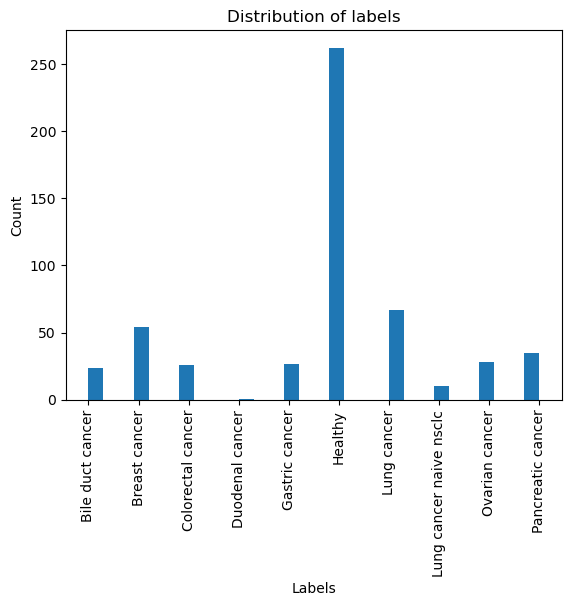

In [5]:
plt.hist(metadata_df["disease"], bins=30)
plt.xlabel("Labels")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.title("Distribution of labels")
plt.show()

In [6]:
# EE87920 or EE87921 are not blood draws
# EE87922 until EE87971 as panel of normals
CANCER_MAP = {"breast": "Breast cancer", "bileduct": "Bile duct cancer", "colorectal": "Colorectal cancer", "gastric": "Gastric cancer", "lung": "Lung cancer naive nsclc", "ovarian": "Ovarian cancer", "pancreatic": "Pancreatic cancer"}

In [7]:
with open("../accessory_files/pon_files.txt") as f:
    pon_ids = [line.split(".")[0] for line in f.readlines()]

# Remove PON data
cris_no_pon = metadata_df[~metadata_df["ID"].isin(pon_ids)]

# Remove samples which are not blood draws
exclude_list = ["EE87920", "EE87921"]
cris_no_pon = cris_no_pon[~cris_no_pon["ID"].isin(exclude_list)]
print("Number of samples without panel of controls is:", len(cris_no_pon))

cris_pon = metadata_df[metadata_df["ID"].isin(pon_ids)]
print("Number of PON samples is:", len(cris_pon))
print("Number of PON with a label Healthy:", len(cris_pon[cris_pon["disease"] == "Healthy"]))

Number of samples without panel of controls is: 482
Number of PON samples is: 50
Number of PON with a label Healthy: 50


In [ ]:
# Finalize Cancer samples
cancer_df = cris_no_pon[cris_no_pon["disease"] != "Healthy"]

# Filter out samples based on the cancer map
cancer_df = cancer_df[cancer_df["disease"].isin(CANCER_MAP.values())]

print("Number of cancer samples in the dataset is", len(cancer_df))
print(cancer_df["disease"].value_counts())

cancer_df.to_csv("../accessory_files/cris_cancer_metadata.csv")

Number of cancer samples in the dataset is 204
disease
Breast cancer              54
Pancreatic cancer          35
Ovarian cancer             28
Gastric cancer             27
Colorectal cancer          26
Bile duct cancer           24
Lung cancer naive nsclc    10
Name: count, dtype: int64


In [9]:
# Save healthy ids and cancer sample ids to txt files for easy of use
cancer_ids = cancer_df["ID"].tolist()
healthy_ids = cris_no_pon[cris_no_pon["disease"] == "Healthy"]["ID"].tolist()

with open("../accessory_files/healthy_ids.txt", "w") as f:
    for item in healthy_ids:
        f.write(item + "\n")

with open("../accessory_files/cancer_ids.txt", "w") as f:
    for item in cancer_ids:
        f.write(item + "\n")